# Music Genre Classification - Dance Valence Ratio

This notebook performs feature engineering by creating a new feature: 'dance_valence_ratio' = danceability / (valence + 1e-6).
This ratio captures the relationship between how danceable a track is and its positivity/mood, which may help distinguish genres like upbeat pop vs. melancholic ones.

## Preparation

In [14]:
import sys
import pandas as pd
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from model.catboost import catboost
from model.xgboost import xgboost
from model.lightgbm import lightgbm
from model.randomforest import randomforest

path_dir = join("..", "..", "data")
df = pd.read_csv(join(path_dir, "preprocessed", "preprocessed_train.csv"))
df_test = pd.read_csv(join(path_dir, "preprocessed", "preprocessed_test.csv"))
df.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,-0.676218,9.0,0.153284,0,26.246030,0.723043,0.003912,-0.598627,0.235,1.014464,452.710724,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.256062,11.0,0.523145,1,11.415395,0.300739,0.045738,-0.629790,0.380,0.425560,438.127835,4,6
2,3,Royal & the Serpent,phuck u,44.0,0.584,0.550185,7.0,0.332191,1,16.154828,0.098922,0.139563,1.055408,0.635,1.226456,401.294156,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,-1.433464,-1.0,-1.572682,1,32.050255,0.967986,0.021076,1.134827,0.501,1.563116,545.978937,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.408517,6.0,0.691321,0,4.016048,0.567741,0.003912,0.583192,0.619,-1.217968,504.127960,4,5


In [15]:
import sys
import pandas as pd
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from model.catboost import catboost
from model.xgboost import xgboost
from model.lightgbm import lightgbm
from model.randomforest import randomforest

path_dir = join("..", "..", "data")
df = pd.read_csv(join(path_dir, "preprocessed", "preprocessed_train.csv"))
df_test = pd.read_csv(join(path_dir, "preprocessed", "preprocessed_test.csv"))
df.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,-0.676218,9.0,0.153284,0,26.246030,0.723043,0.003912,-0.598627,0.235,1.014464,452.710724,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.256062,11.0,0.523145,1,11.415395,0.300739,0.045738,-0.629790,0.380,0.425560,438.127835,4,6
2,3,Royal & the Serpent,phuck u,44.0,0.584,0.550185,7.0,0.332191,1,16.154828,0.098922,0.139563,1.055408,0.635,1.226456,401.294156,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,-1.433464,-1.0,-1.572682,1,32.050255,0.967986,0.021076,1.134827,0.501,1.563116,545.978937,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.408517,6.0,0.691321,0,4.016048,0.567741,0.003912,0.583192,0.619,-1.217968,504.127960,4,5


## Feature Engineering

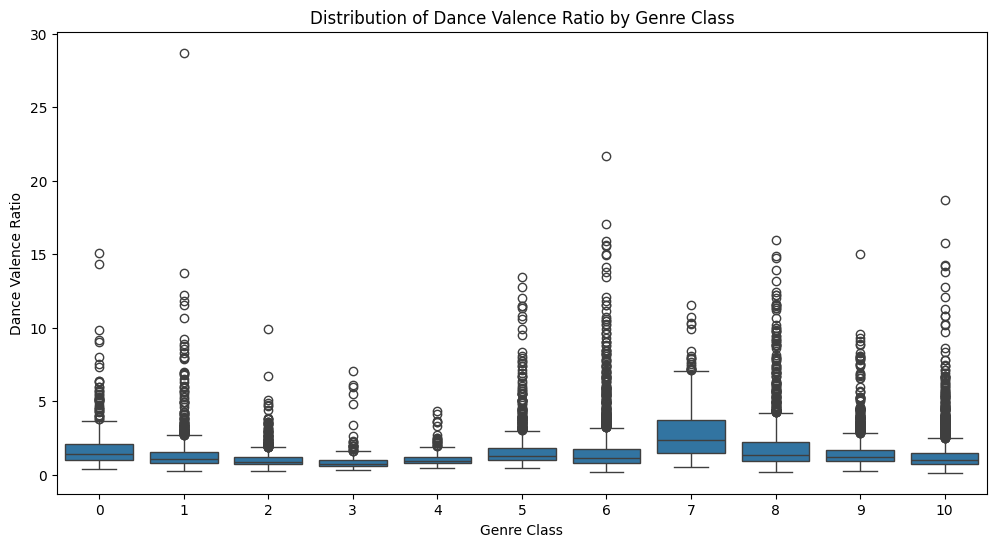

In [16]:
epsilon = 1e-6
df['dance_valence_ratio'] = df['danceability'] / (df['valence'] + epsilon)
df_test['dance_valence_ratio'] = df_test['danceability'] / (df_test['valence'] + epsilon)

df = df.drop(['Id', 'Artist Name', 'Track Name'], axis=1)
df_test = df_test.drop(['Id', 'Artist Name', 'Track Name'], axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y='dance_valence_ratio', data=df)
plt.title('Distribution of Dance Valence Ratio by Genre Class')
plt.xlabel('Genre Class')
plt.ylabel('Dance Valence Ratio')
plt.show()

## Modelling

In [17]:
catboost(df=df, df_test=df_test)
xgboost(df=df, df_test=df_test)
lightgbm(df=df, df_test=df_test)
randomforest(df=df, df_test=df_test)


==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5243 | prec:0.5842 | rec:0.5771 | f1:0.5773

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5189 | prec:0.5653 | rec:0.5456 | f1:0.5503

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5290 | prec:0.5733 | rec:0.5780 | f1:0.5717

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5134 | prec:0.5678 | rec:0.5654 | f1:0.5646

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5207 | prec:0.5799 | rec:0.5686 | f1:0.5690

==== Mean metrics ====
Acc: 0.5213
Prec: 0.5741
F1: 0.5666
Rec: 0.5669

==== Fold 1 results for XGBClassifier ====
Fold 1 -> acc:0.5014 | prec:0.5834 | rec:0.5653 | f1:0.5712

==== Fold 2 results for XGBClassifier ====
Fold 2 -> acc:0.4953 | prec:0.5493 | rec:0.5251 | f1:0.5339

==== Fold 3 results for XGBClassifier ====
Fold 3 -> acc:0.4974 | prec:0.5523 | rec:0.5457 | f1:0.5460

==== Fold 4 results for XGBClassifier ====
Fold 4 -> acc:0.4918 | prec

## Submit

In [18]:
catboost(df=df, df_test=df_test, author="ThaiTu", path_to_log_csv=join('..', '..', 'log', 'dance_valence', 'experiment_log.csv'), name_folder="dance_valence", name_feature='dance_valence_ratio', print_log=False, save_log=True, save_model=True, save_submission=True)
xgboost(df=df, df_test=df_test, author="ThaiTu", path_to_log_csv=join('..', '..', 'log', 'dance_valence', 'experiment_log.csv'), name_folder="dance_valence", name_feature='dance_valence_ratio', print_log=False, save_log=True, save_model=True, save_submission=True)
lightgbm(df=df, df_test=df_test, author="ThaiTu", path_to_log_csv=join('..', '..', 'log', 'dance_valence', 'experiment_log.csv'), name_folder="dance_valence", name_feature='dance_valence_ratio', print_log=False, save_log=True, save_model=True, save_submission=True)
randomforest(df=df, df_test=df_test, author="ThaiTu", path_to_log_csv=join('..', '..', 'log', 'dance_valence', 'experiment_log.csv'), name_folder="dance_valence", name_feature='dance_valence_ratio', print_log=False, save_log=True, save_model=True, save_submission=True)

Logged experiment to ..\..\log\dance_valence\experiment_log.csv
✅ Model saved to ..\..\log\dance_valence\Model Pickles\CatBoostClassifier\CatBoostClassifier_dance_valence_ratio.pkl
📤 Submission file saved to ..\..\data\submissions\dance_valence\CatBoostClassifier\submission_CatBoostClassifier_dance_valence_ratio.csv
Logged experiment to ..\..\log\dance_valence\experiment_log.csv
✅ Model saved to ..\..\log\dance_valence\Model Pickles\XGBClassifier\XGBClassifier_dance_valence_ratio.pkl
📤 Submission file saved to ..\..\data\submissions\dance_valence\XGBClassifier\submission_XGBClassifier_dance_valence_ratio.csv
Logged experiment to ..\..\log\dance_valence\experiment_log.csv
✅ Model saved to ..\..\log\dance_valence\Model Pickles\LGBMClassifier\LGBMClassifier_dance_valence_ratio.pkl
📤 Submission file saved to ..\..\data\submissions\dance_valence\LGBMClassifier\submission_LGBMClassifier_dance_valence_ratio.csv
Logged experiment to ..\..\log\dance_valence\experiment_log.csv
✅ Model saved to .

## Result

<img src="images/output_kaggle_dance_valence.png" width="800">

In [ ]:
# df.to_csv(join(path_dir, "feature_engineered", "dance_valence", "dance_valence_train.csv"), index=False)
# df_test.to_csv(join(path_dir, "feature_engineered", "dance_valence", "dance_valence_test.csv"), index=False)

NameError: name 'df_test' is not defined

# The end